# RIS 偏析 profile 后处理绘图（模拟 vs 实验）

- 模拟数据：数据集文件夹下 `dose0.5dpa/`、`dose3dpa/` 中的 `Cr/Ni/Si_final.csv`（取最后一行稳态 profile，x=0 为晶界 GB）
- **自动检测数据集**：若当前目录直接含 `dose*` 文件夹则处理当前目录；否则自动遍历含数据的子文件夹（如 `1/`、`2/`）
- **x 方向总长 `L_X` 在开头作为全局变量输入**（当前数据为 20 nm）；模拟 profile 关于 GB 镜像，得到 -L_X ~ +L_X nm 的完整偏析 profile；浓度由原子分数换算为 at.%
- **输出时自动截断到 ±`X_CUT`（默认 15 nm）以适配实验数据范围**；高斯卷积在全域 profile 上进行、仅在绘图时截断，避免边界伪影
- 实验数据：各数据集 `experiments/` 下的 `Cr/Ni/Si + dose.csv`（x / nm，y / at.%），画成点线图
- 第一轮：原始模拟 profile vs 实验；第二轮：对模拟 profile 施加 1 nm 分辨率（FWHM）的高斯卷积后 vs 实验
- 绘图样式按 Elsevier 期刊风格（Arial 字体、单栏 90 mm 图宽、色盲友好配色）；保存的 PNG 为 600 dpi，PDF 为矢量图

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

# notebook 内嵌图用 retina 2x 渲染，避免预览发糊（保存的文件不受影响）
%config InlineBackend.figure_format = 'retina'

# ---------------- Elsevier 风格全局设置 ----------------
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':        8,
    'axes.labelsize':   9,
    'axes.titlesize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  7.5,
    'axes.linewidth':   0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':  'in',
    'ytick.direction':  'in',
    'xtick.top':        True,
    'ytick.right':      True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth':  1.2,
    'legend.frameon':   False,
    'figure.dpi':       150,  # 内嵌预览分辨率（配合 retina 实际 300 dpi）
    'savefig.dpi':      600,
    'savefig.bbox':     'tight',
    'pdf.fonttype':     42,   # 嵌入 TrueType 字体，便于期刊编辑
    'ps.fonttype':      42,
})

# Elsevier 单栏宽约 90 mm ≈ 3.54 in
FIG_W, FIG_H = 3.54, 2.66

In [2]:
# ---------------- 全局输入参数 ----------------
L_X     = 15.0    # 模拟 x 方向总长 / nm（GB 一侧，镜像后 profile 覆盖 -L_X ~ +L_X）
X_CUT   = 15.0    # 输出截断范围 / nm：绘图时只保留 |x| <= X_CUT，以适配实验数据
FWHM_NM  = 1.0     # 仪器分辨率（高斯卷积 FWHM）/ nm
FWHM_NM2 = 2.0     # 第二组分辨率（高斯卷积 FWHM）/ nm
TIFF_DPI = 1000   # TIFF 输出分辨率（Elsevier 线图要求）

# ---------------- 路径与其他配置 ----------------
ROOT     = Path('.')
DOSES    = ['0.5dpa', '3.0dpa']             # 对应文件夹 dose0.5dpa / dose3dpa
ELEMENTS = ['Cr', 'Ni', 'Si']

# 自动检测数据集：当前目录直接含数据 -> ['.']；否则找含 dose 文件夹的子目录（如 1/ 2/）
if (ROOT / f'dose{DOSES[0]}').is_dir():
    DATASETS = ['.']
else:
    DATASETS = sorted(p.name for p in ROOT.iterdir()
                      if p.is_dir() and (p / f'dose{DOSES[0]}').is_dir())
assert DATASETS, '未找到任何包含 dose 数据的文件夹！'
print('检测到数据集:', DATASETS)

def figdir(ds):
    d = ROOT / ds / 'figures'
    d.mkdir(exist_ok=True)
    return d

# Okabe–Ito 色盲友好配色
COLORS = {'Cr': '#0072B2',   # 蓝
          'Ni': '#D55E00',   # 朱红
          'Si': '#009E73'}   # 青绿

dose_label = {d: d.replace('dpa', ' dpa') for d in DOSES}

检测到数据集: ['.']


In [3]:
# ---------------- 数据读取 ----------------
def load_sim(ds, dose, element):
    """读取模拟 profile（取最后一行），镜像成 -L_X ~ +L_X nm，返回 (x, c/at.%)。"""
    data = np.loadtxt(ROOT / ds / f'dose{dose}' / f'{element}_final.csv', delimiter=',')
    c_half = np.atleast_2d(data)[-1] * 100.0          # 原子分数 -> at.%
    x_half = np.linspace(0.0, L_X, c_half.size)       # 0 (GB) -> L_X nm
    # 关于 x=0 镜像（GB 点不重复）
    x = np.concatenate([-x_half[::-1][:-1], x_half])
    c = np.concatenate([ c_half[::-1][:-1], c_half])
    return x, c

def load_exp(ds, dose, element):
    """读取实验 profile，返回 (x/nm, c/at.%)。"""
    fname = ROOT / ds / 'experiments' / f'{element}{dose}.csv'
    if not fname.exists():   # 目录名 3.0dpa ↔ 实验文件 Cr3dpa.csv 兼容
        fname = ROOT / ds / 'experiments' / f"{element}{dose.replace('.0dpa', 'dpa')}.csv"
    data = np.genfromtxt(fname, delimiter=',', skip_header=1)
    order = np.argsort(data[:, 0])
    return data[order, 0], data[order, 1]

sim = {(s, d, e): load_sim(s, d, e) for s in DATASETS for d in DOSES for e in ELEMENTS}
exp = {(s, d, e): load_exp(s, d, e) for s in DATASETS for d in DOSES for e in ELEMENTS}

for (s, d, e), (x, c) in sim.items():
    print(f'sim [{s}] {d:>7s} {e}: {x.size} pts, x ∈ [{x.min():.0f}, {x.max():.0f}] nm, '
          f'c(GB) = {c[x.size // 2]:.2f} at.%, c(bulk) = {c[-1]:.2f} at.%')

sim [.]  0.5dpa Cr: 99 pts, x ∈ [-15, 15] nm, c(GB) = 6.20 at.%, c(bulk) = 20.00 at.%
sim [.]  0.5dpa Ni: 99 pts, x ∈ [-15, 15] nm, c(GB) = 20.42 at.%, c(bulk) = 8.90 at.%
sim [.]  0.5dpa Si: 99 pts, x ∈ [-15, 15] nm, c(GB) = 8.81 at.%, c(bulk) = 0.27 at.%
sim [.]  3.0dpa Cr: 99 pts, x ∈ [-15, 15] nm, c(GB) = 3.05 at.%, c(bulk) = 20.00 at.%
sim [.]  3.0dpa Ni: 99 pts, x ∈ [-15, 15] nm, c(GB) = 22.58 at.%, c(bulk) = 8.90 at.%
sim [.]  3.0dpa Si: 99 pts, x ∈ [-15, 15] nm, c(GB) = 31.58 at.%, c(bulk) = 0.27 at.%


In [4]:
# ---------------- 1 nm 分辨率高斯卷积 ----------------
def convolve_profile(x, c, fwhm=FWHM_NM, dx_fine=0.02):
    """先插值到均匀细网格，再做 FWHM=fwhm 的高斯卷积（边界取最近值延拓）。"""
    x_fine = np.arange(x.min(), x.max() + dx_fine / 2, dx_fine)
    c_fine = np.interp(x_fine, x, c)
    sigma_pts = (fwhm / 2.3548) / dx_fine     # FWHM -> sigma，再换成网格点数
    c_conv = gaussian_filter1d(c_fine, sigma_pts, mode='nearest')
    return x_fine, c_conv

sim_conv  = {k: convolve_profile(x, c, fwhm=FWHM_NM ) for k, (x, c) in sim.items()}
sim_conv2 = {k: convolve_profile(x, c, fwhm=FWHM_NM2) for k, (x, c) in sim.items()}

# 按 FWHM 查表，绘图函数按分辨率取用对应的卷积结果
SIM_CONV = {FWHM_NM: sim_conv, FWHM_NM2: sim_conv2}

def cut(x, c, xmax=None):
    """输出截断：只保留 |x| <= xmax（默认 X_CUT）的数据，适配实验范围。"""
    xmax = X_CUT if xmax is None else xmax
    m = np.abs(x) <= xmax
    return x[m], c[m]

In [5]:
# ---------------- 绘图函数 ----------------
def ds_tag(ds):
    return '' if ds == '.' else f'Set {ds}, '

def plot_compare(ds, dose, element, convolved=False, fwhm=FWHM_NM, save=True):
    xs, cs = cut(*sim[(ds, dose, element)])     # 截断到 ±X_CUT
    xe, ce = cut(*exp[(ds, dose, element)])
    color  = COLORS[element]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    # 实验：点线图（开口圆点 + 细虚线）
    ax.plot(xe, ce, ls='--', lw=0.8, marker='o', ms=3.5,
            mfc='white', mec=color, mew=0.8, color=color, alpha=0.85,
            label='Experiment (APT)')

    if convolved:
        # 原始模拟 profile 作对照（细灰线）
        ax.plot(xs, cs, ls=':', lw=0.9, color='0.45', label='Simulation (raw)')
        xc, cc = cut(*SIM_CONV[fwhm][(ds, dose, element)])
        ax.plot(xc, cc, ls='-', lw=1.4, color=color,
                label=f'Simulation ({fwhm:g} nm conv.)')
    else:
        ax.plot(xs, cs, ls='-', lw=1.4, color=color, label='Simulation')

    ax.axvline(0.0, ls='-', lw=0.6, color='0.6', zorder=0)   # GB 位置
    ax.set_xlim(-X_CUT, X_CUT)
    ax.set_xlabel('Distance from GB (nm)')
    ax.set_ylabel(f'{element} concentration (at.%)')
    ax.legend(loc='best', handlelength=1.8)
    ax.text(0.03, 0.94, f'{ds_tag(ds)}{element}, {dose_label[dose]}',
            transform=ax.transAxes, fontsize=8.5, fontweight='bold', va='top')

    if save:
        # 1 nm 保持既有文件名 *_conv；其余分辨率用 *_conv{fwhm}nm
        if not convolved:
            tag = 'raw'
        else:
            tag = 'conv' if fwhm == FWHM_NM else f'conv{fwhm:g}nm'
        stem = figdir(ds) / f'{element}_{dose}_{tag}'
        for ext in ('png', 'pdf'):
            fig.savefig(f'{stem}.{ext}')
        fig.savefig(f'{stem}.tiff', dpi=TIFF_DPI,
                    pil_kwargs={'compression': 'tiff_lzw'})   # 1000 dpi LZW 压缩 TIFF
    return fig

## 第一轮：原始模拟 profile vs 实验

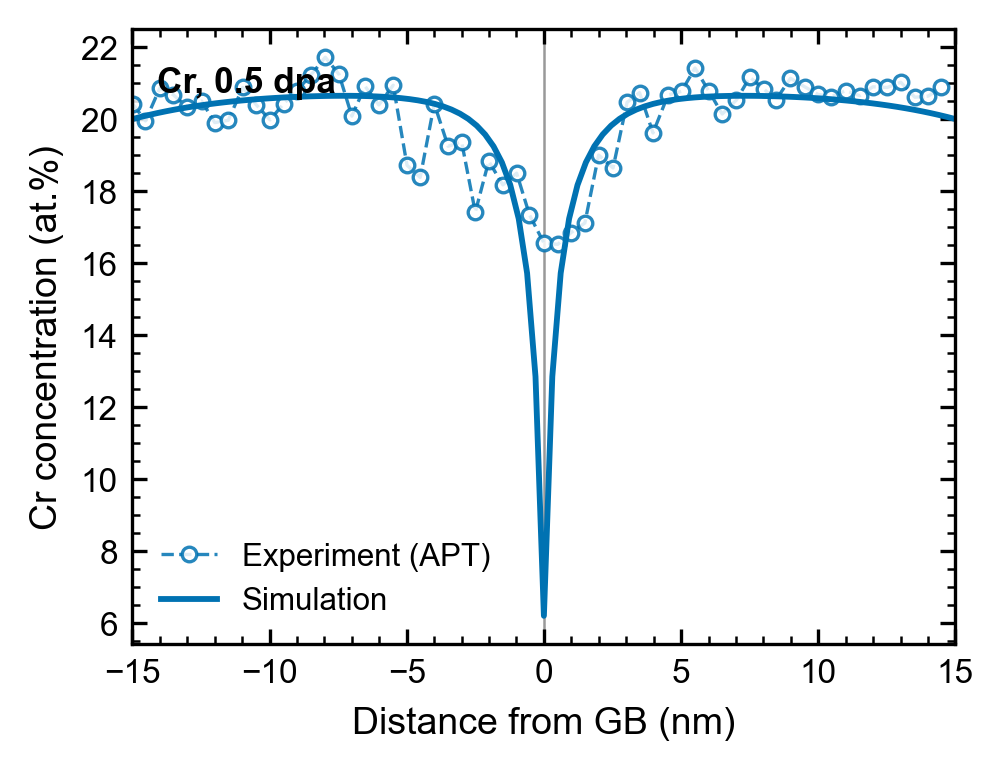

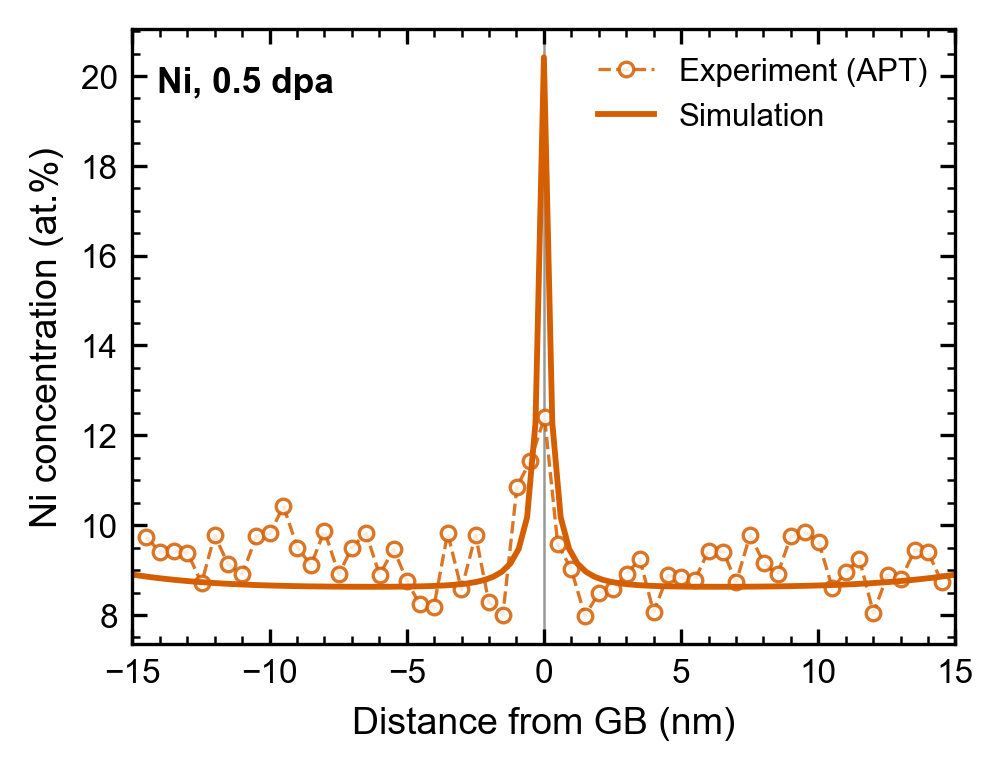

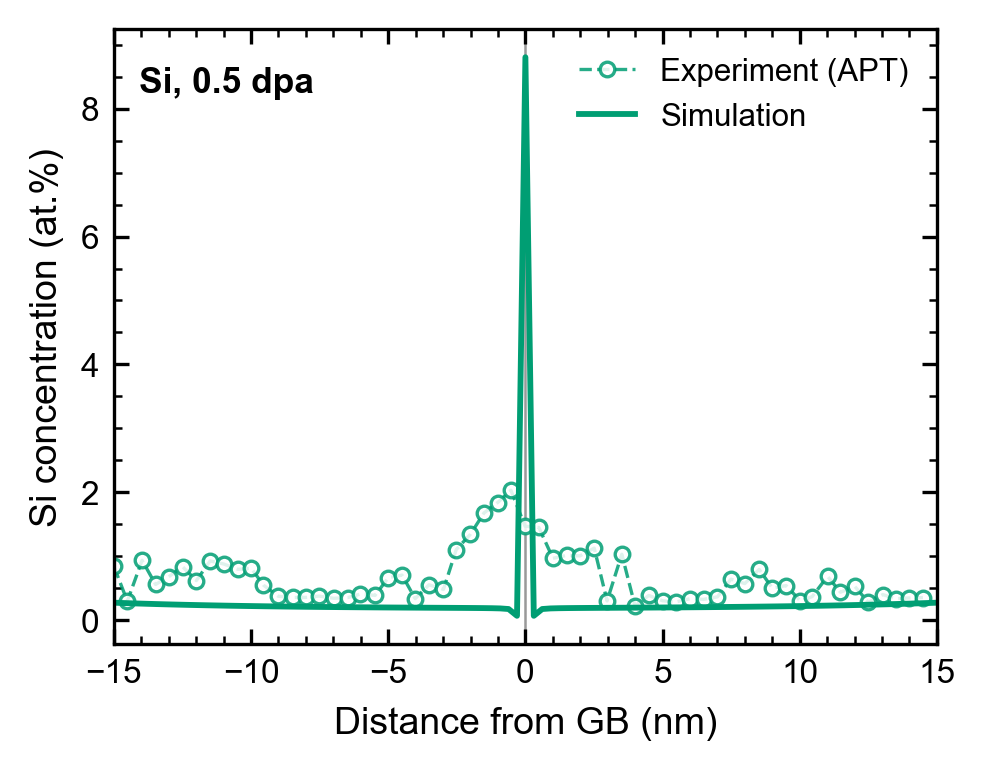

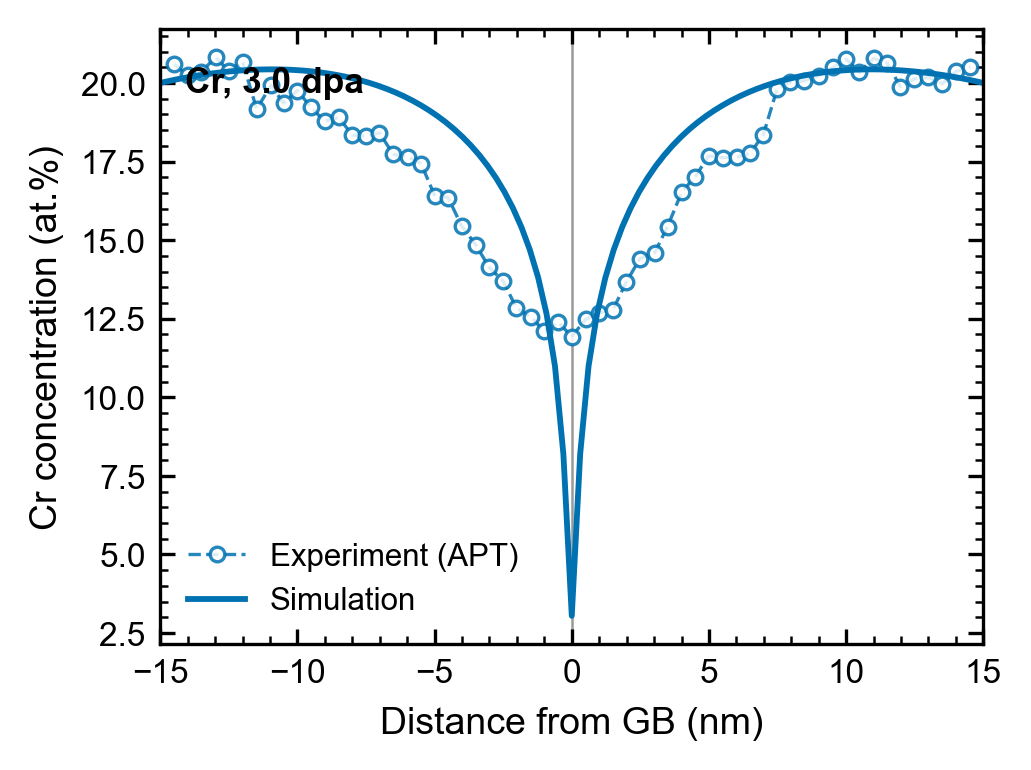

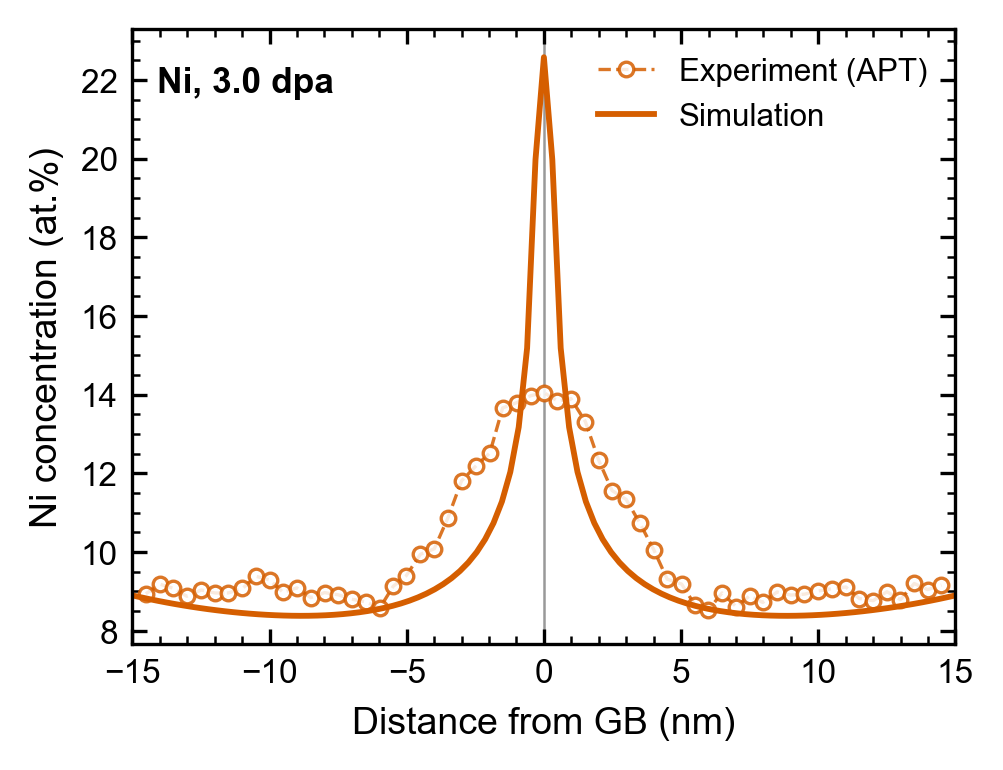

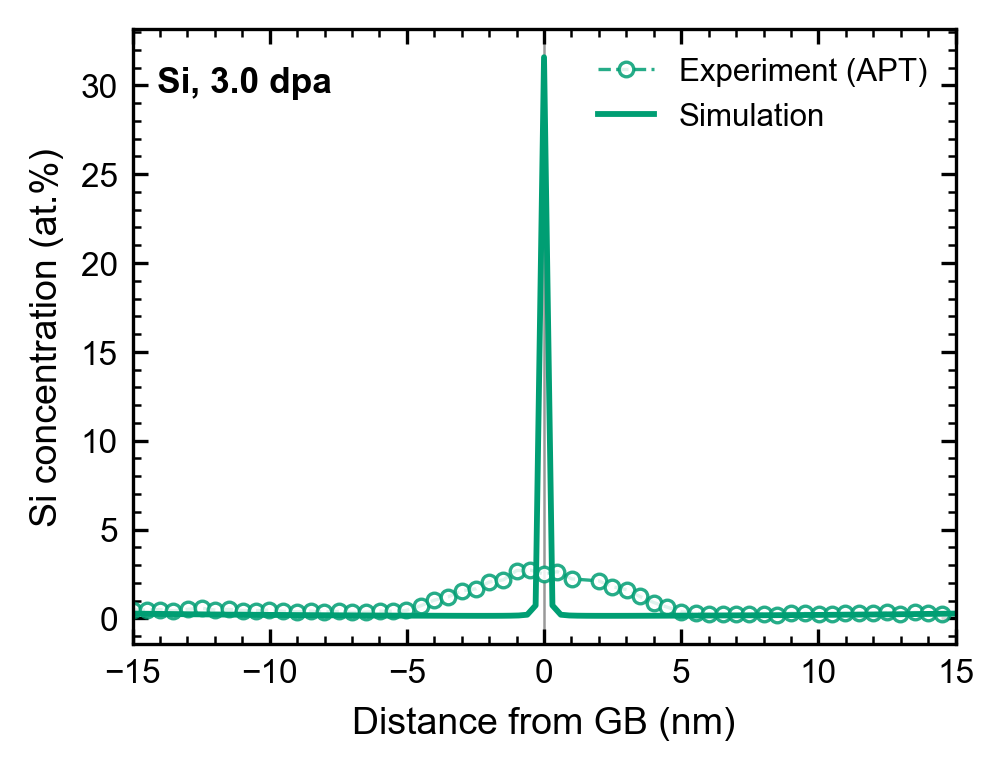

In [6]:
for ds in DATASETS:
    for dose in DOSES:
        for element in ELEMENTS:
            plot_compare(ds, dose, element, convolved=False)
plt.show()

## 第二轮：1 nm 分辨率卷积后的模拟 profile vs 实验

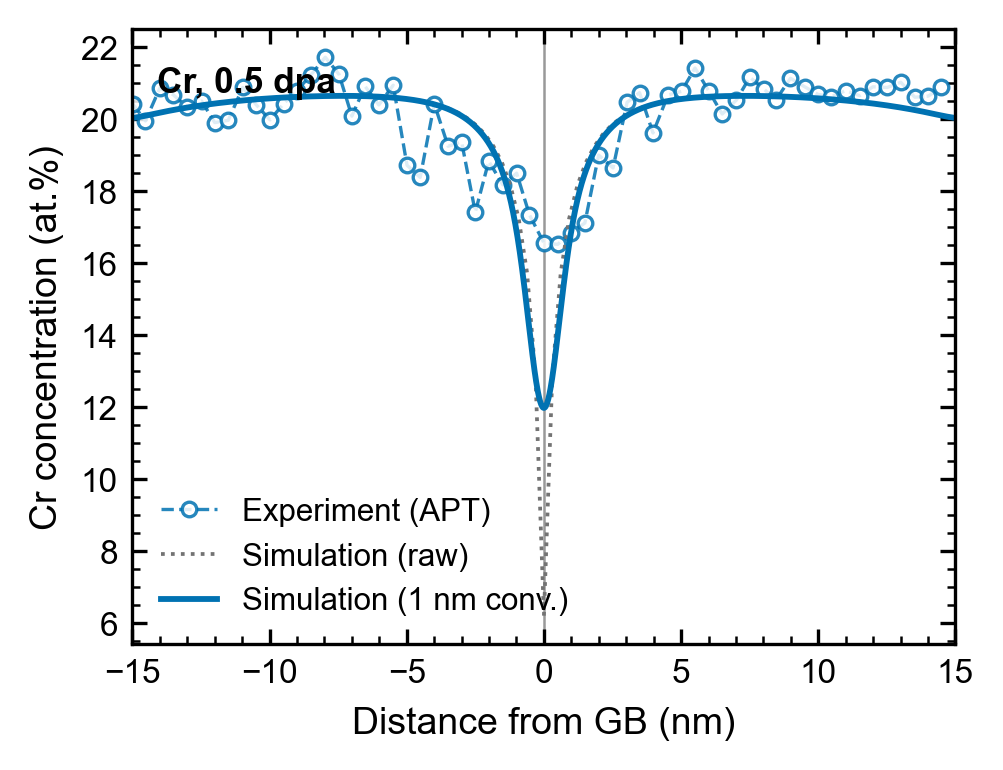

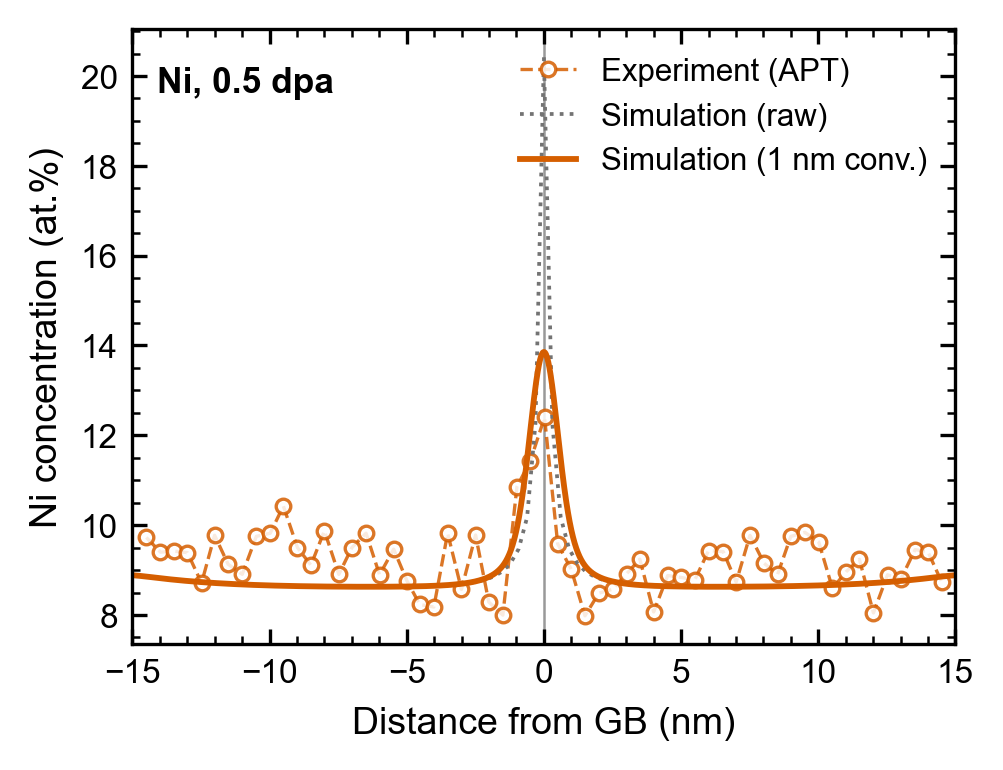

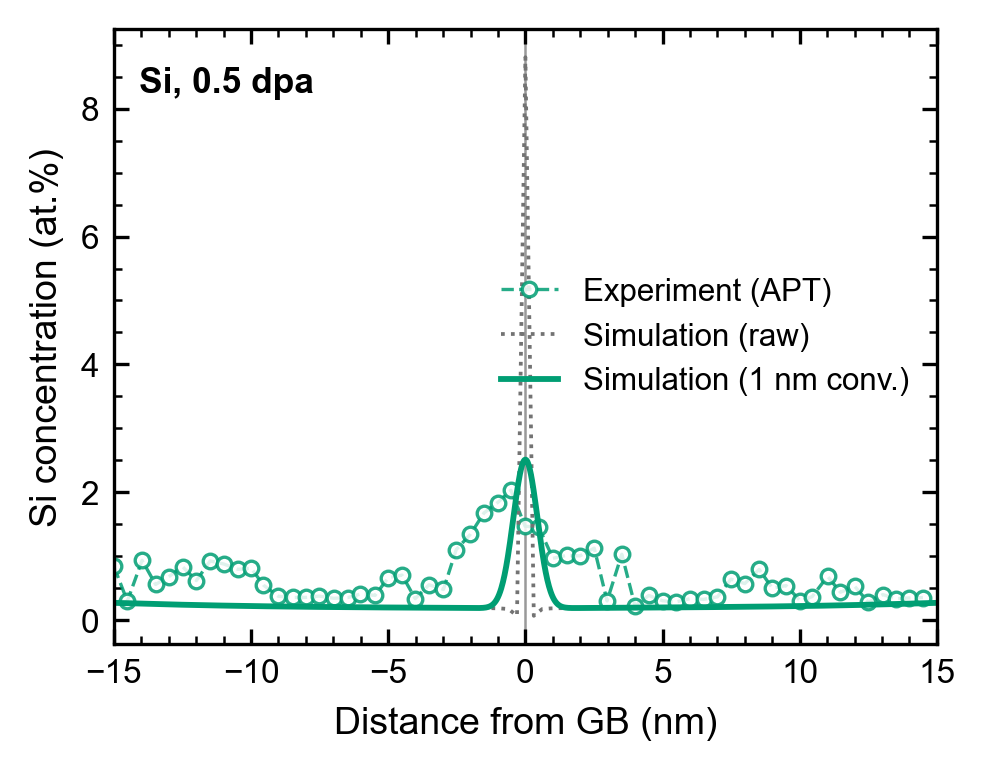

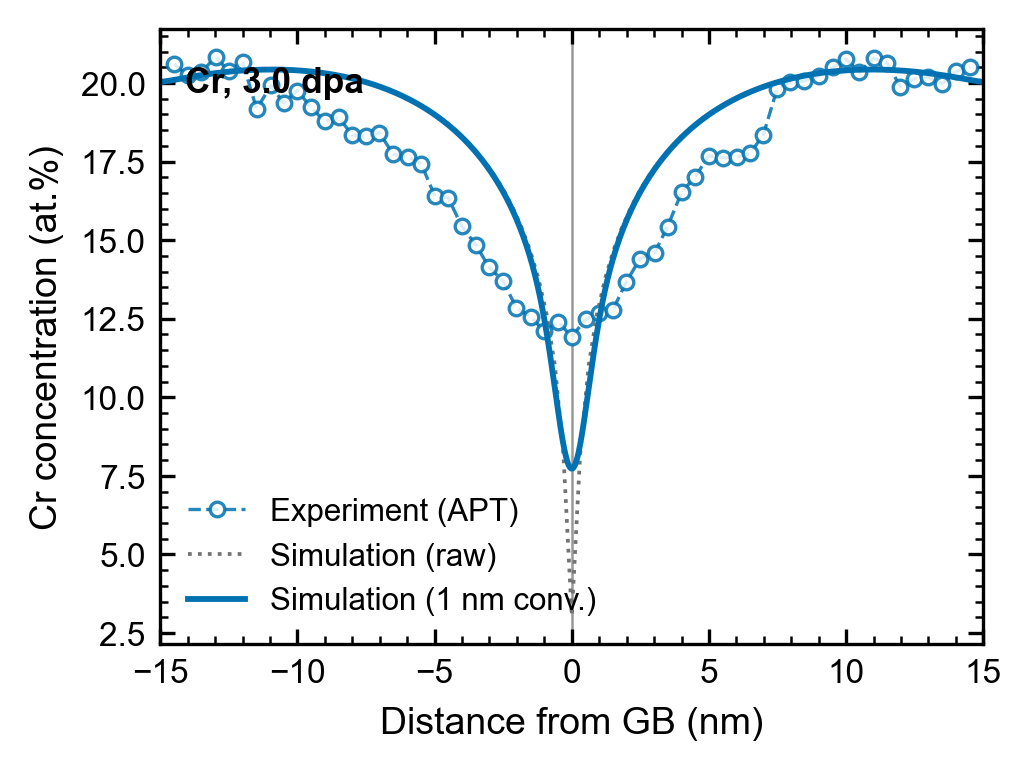

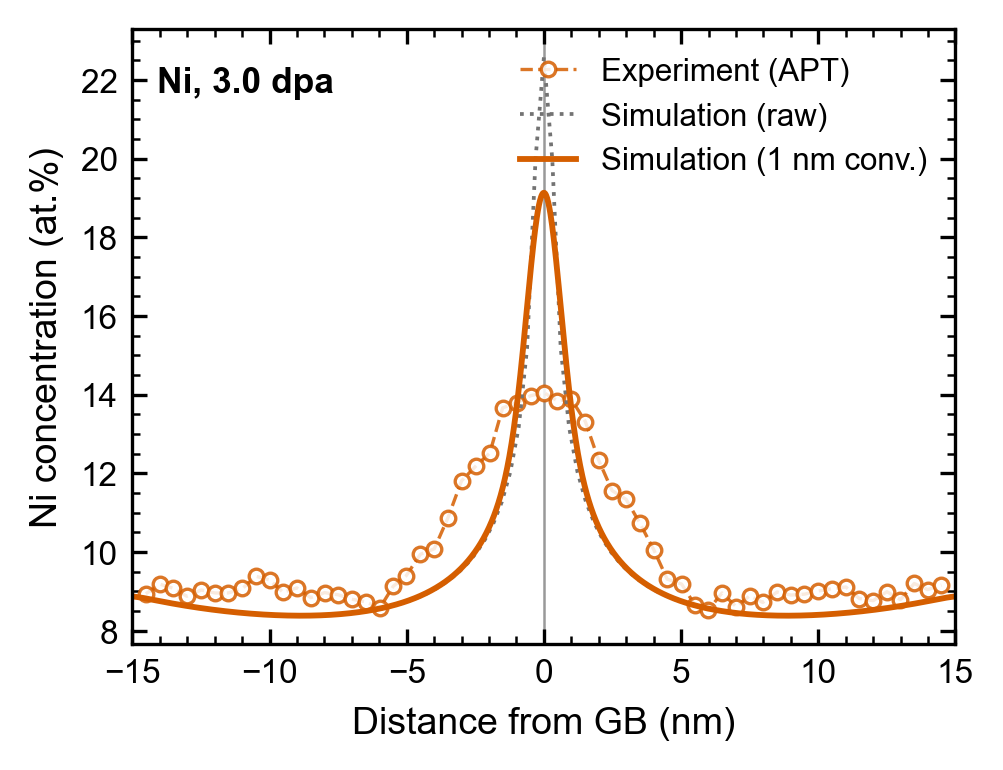

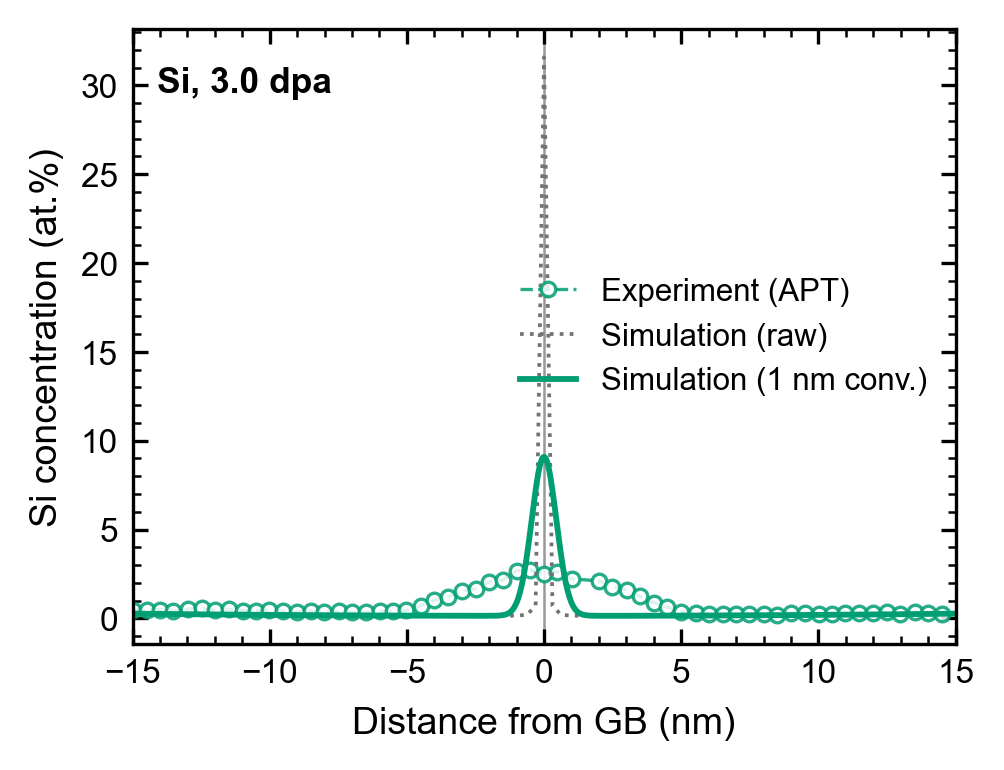

In [7]:
for ds in DATASETS:
    for dose in DOSES:
        for element in ELEMENTS:
            plot_compare(ds, dose, element, convolved=True)
plt.show()

## 第三轮：2 nm 分辨率卷积后的模拟 profile vs 实验

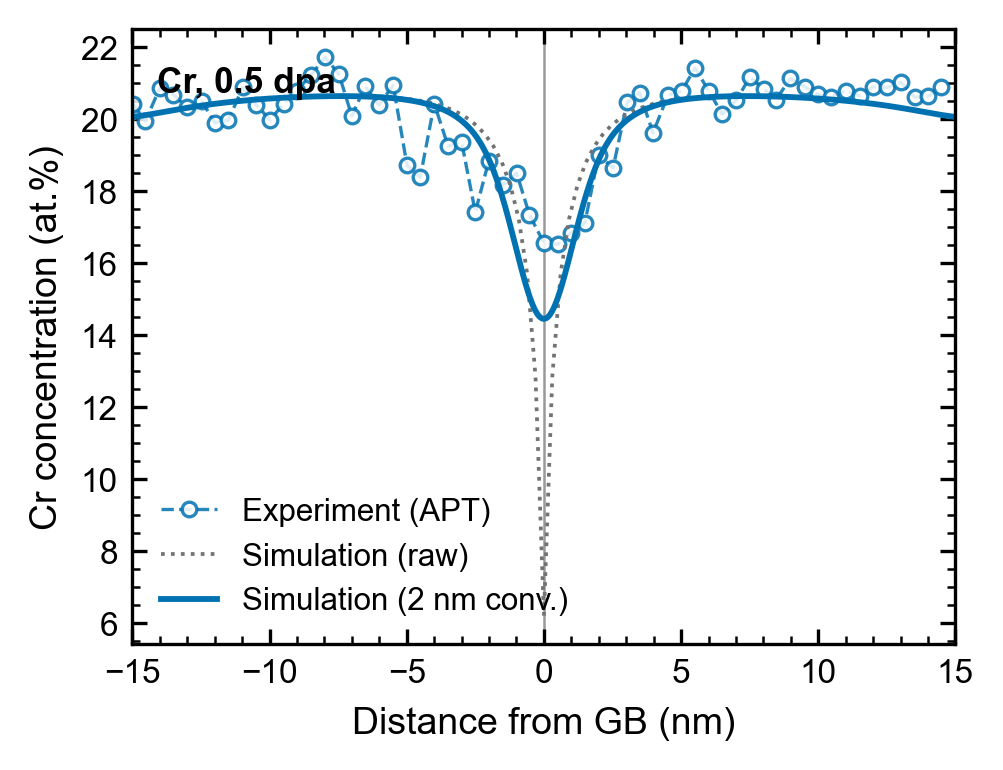

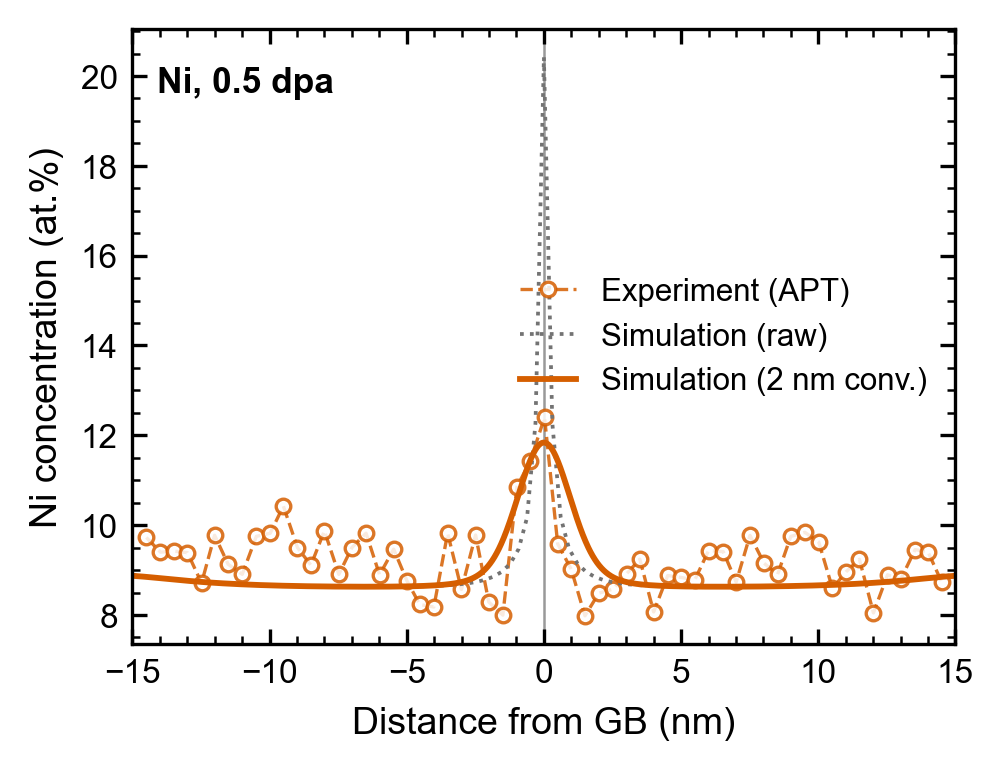

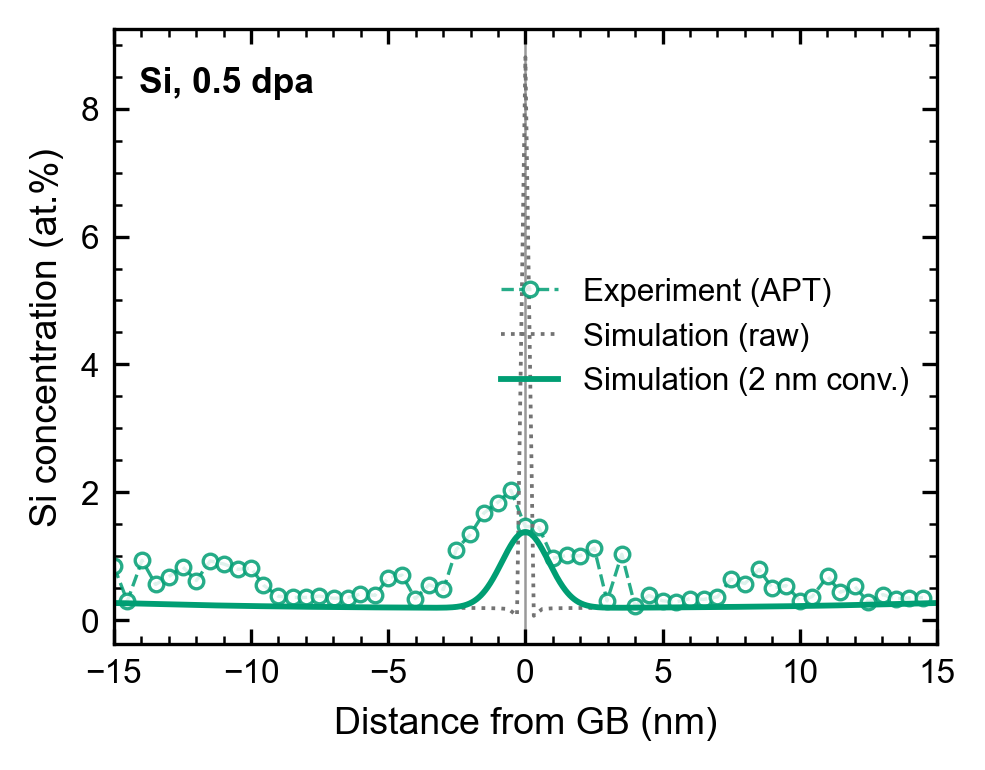

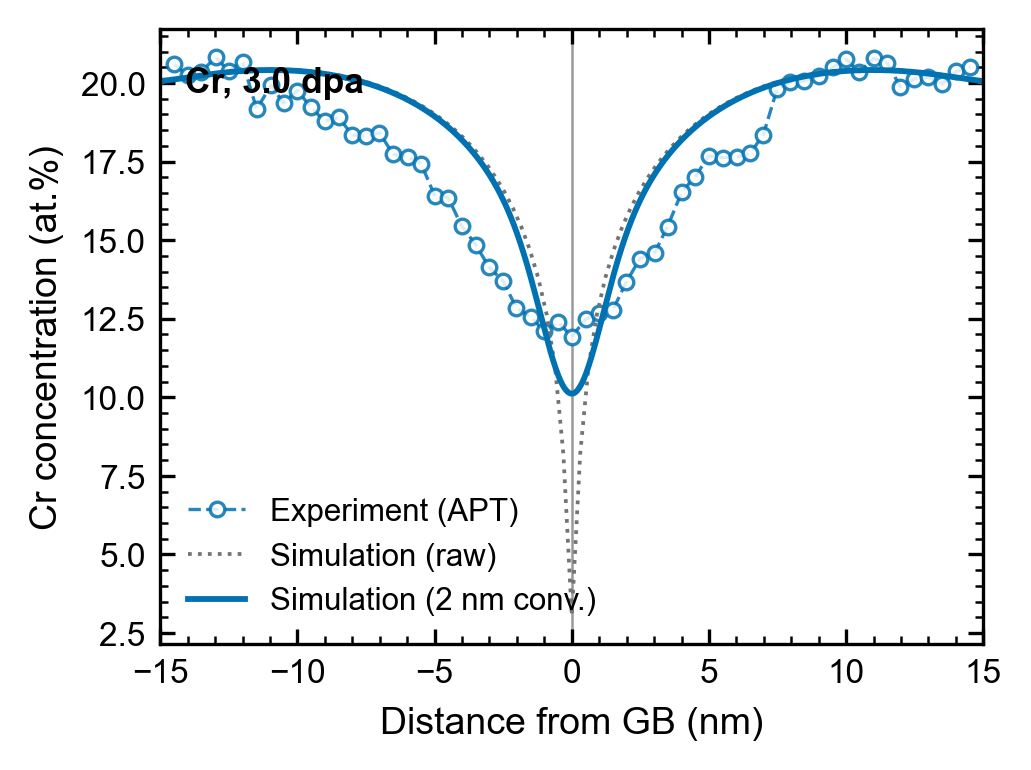

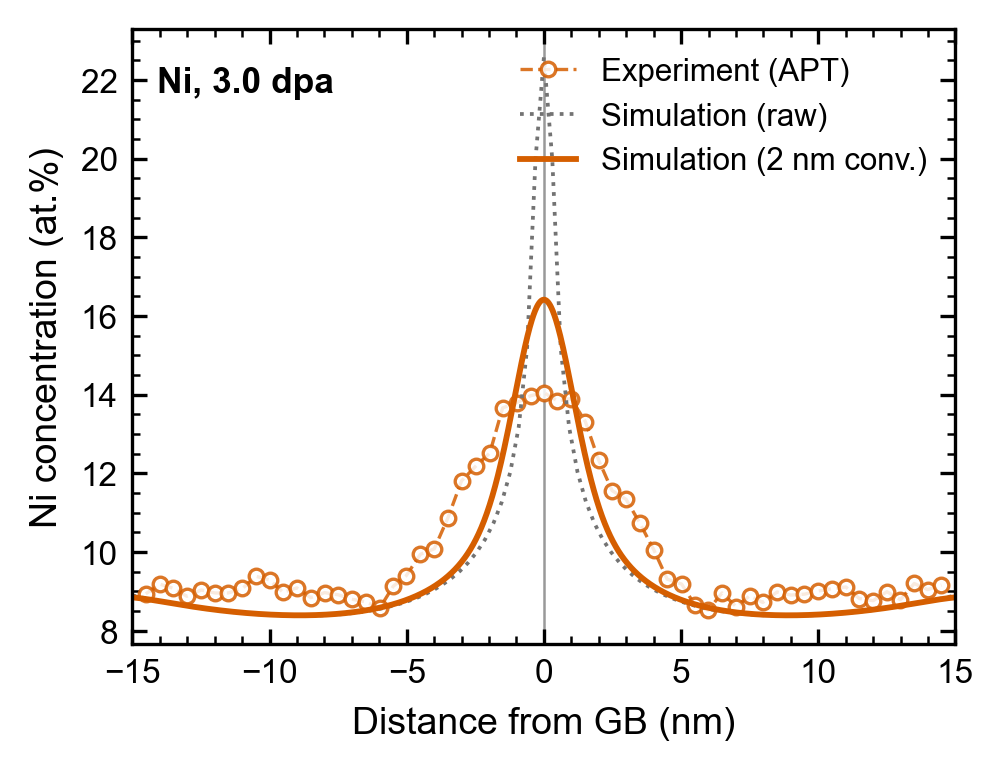

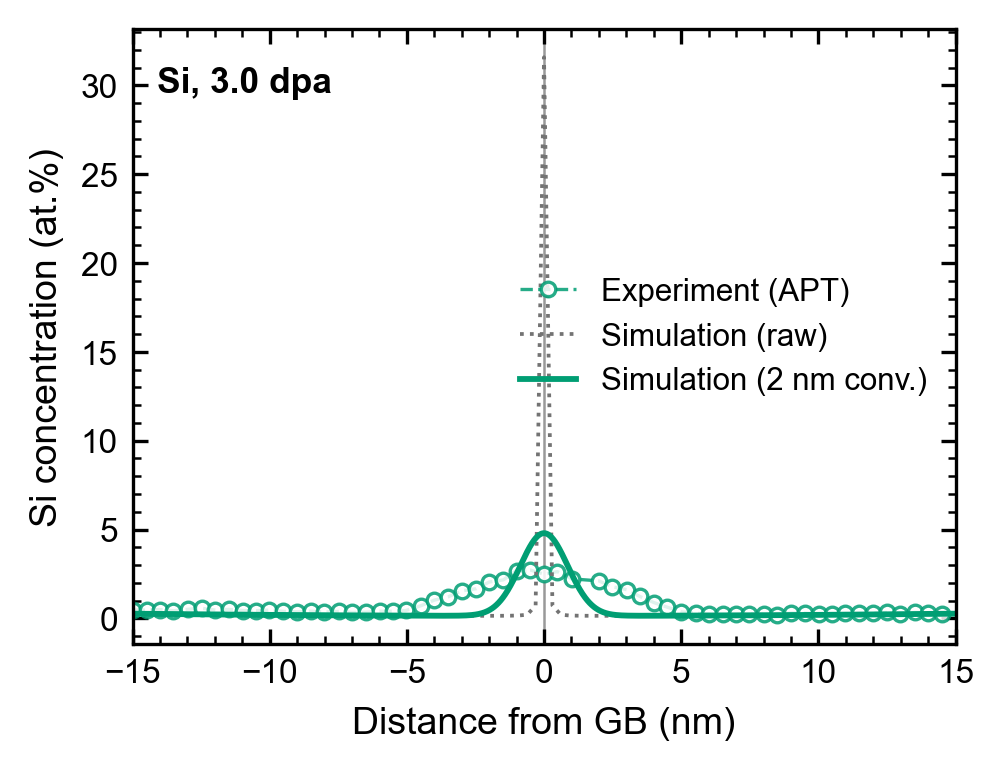

In [8]:
for ds in DATASETS:
    for dose in DOSES:
        for element in ELEMENTS:
            plot_compare(ds, dose, element, convolved=True, fwhm=FWHM_NM2)
plt.show()

## 汇总图（可选）：2 行（dose）× 3 列（元素）总览

双栏排版（约 190 mm 宽），便于放进正文做整体对比。

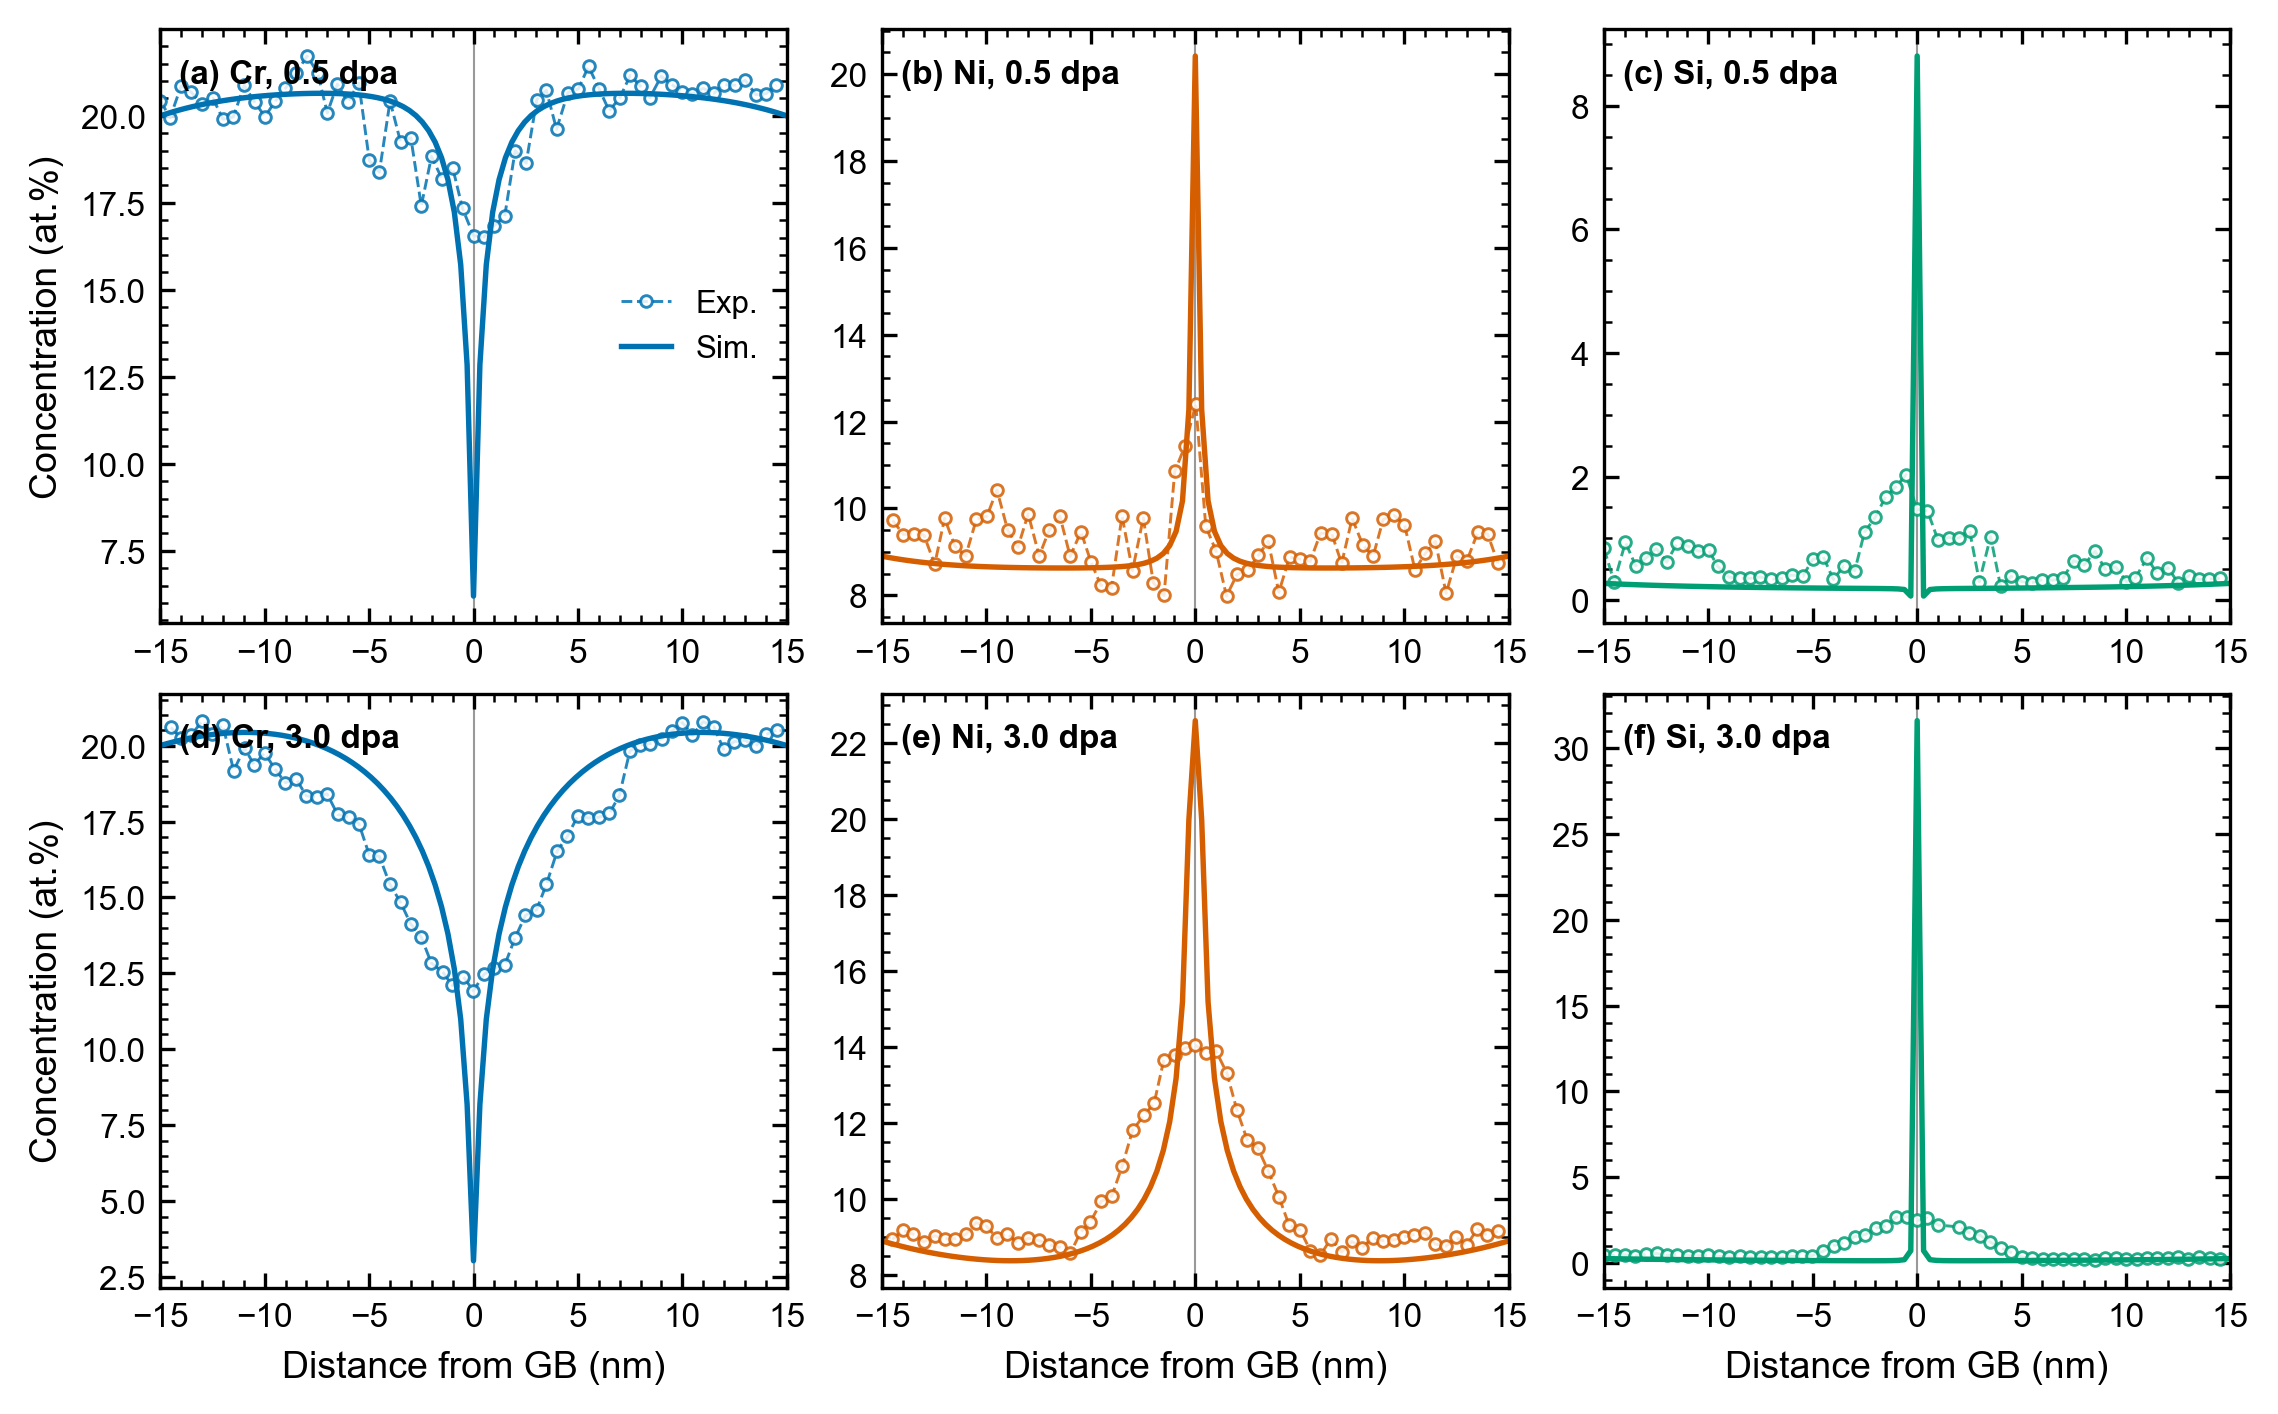

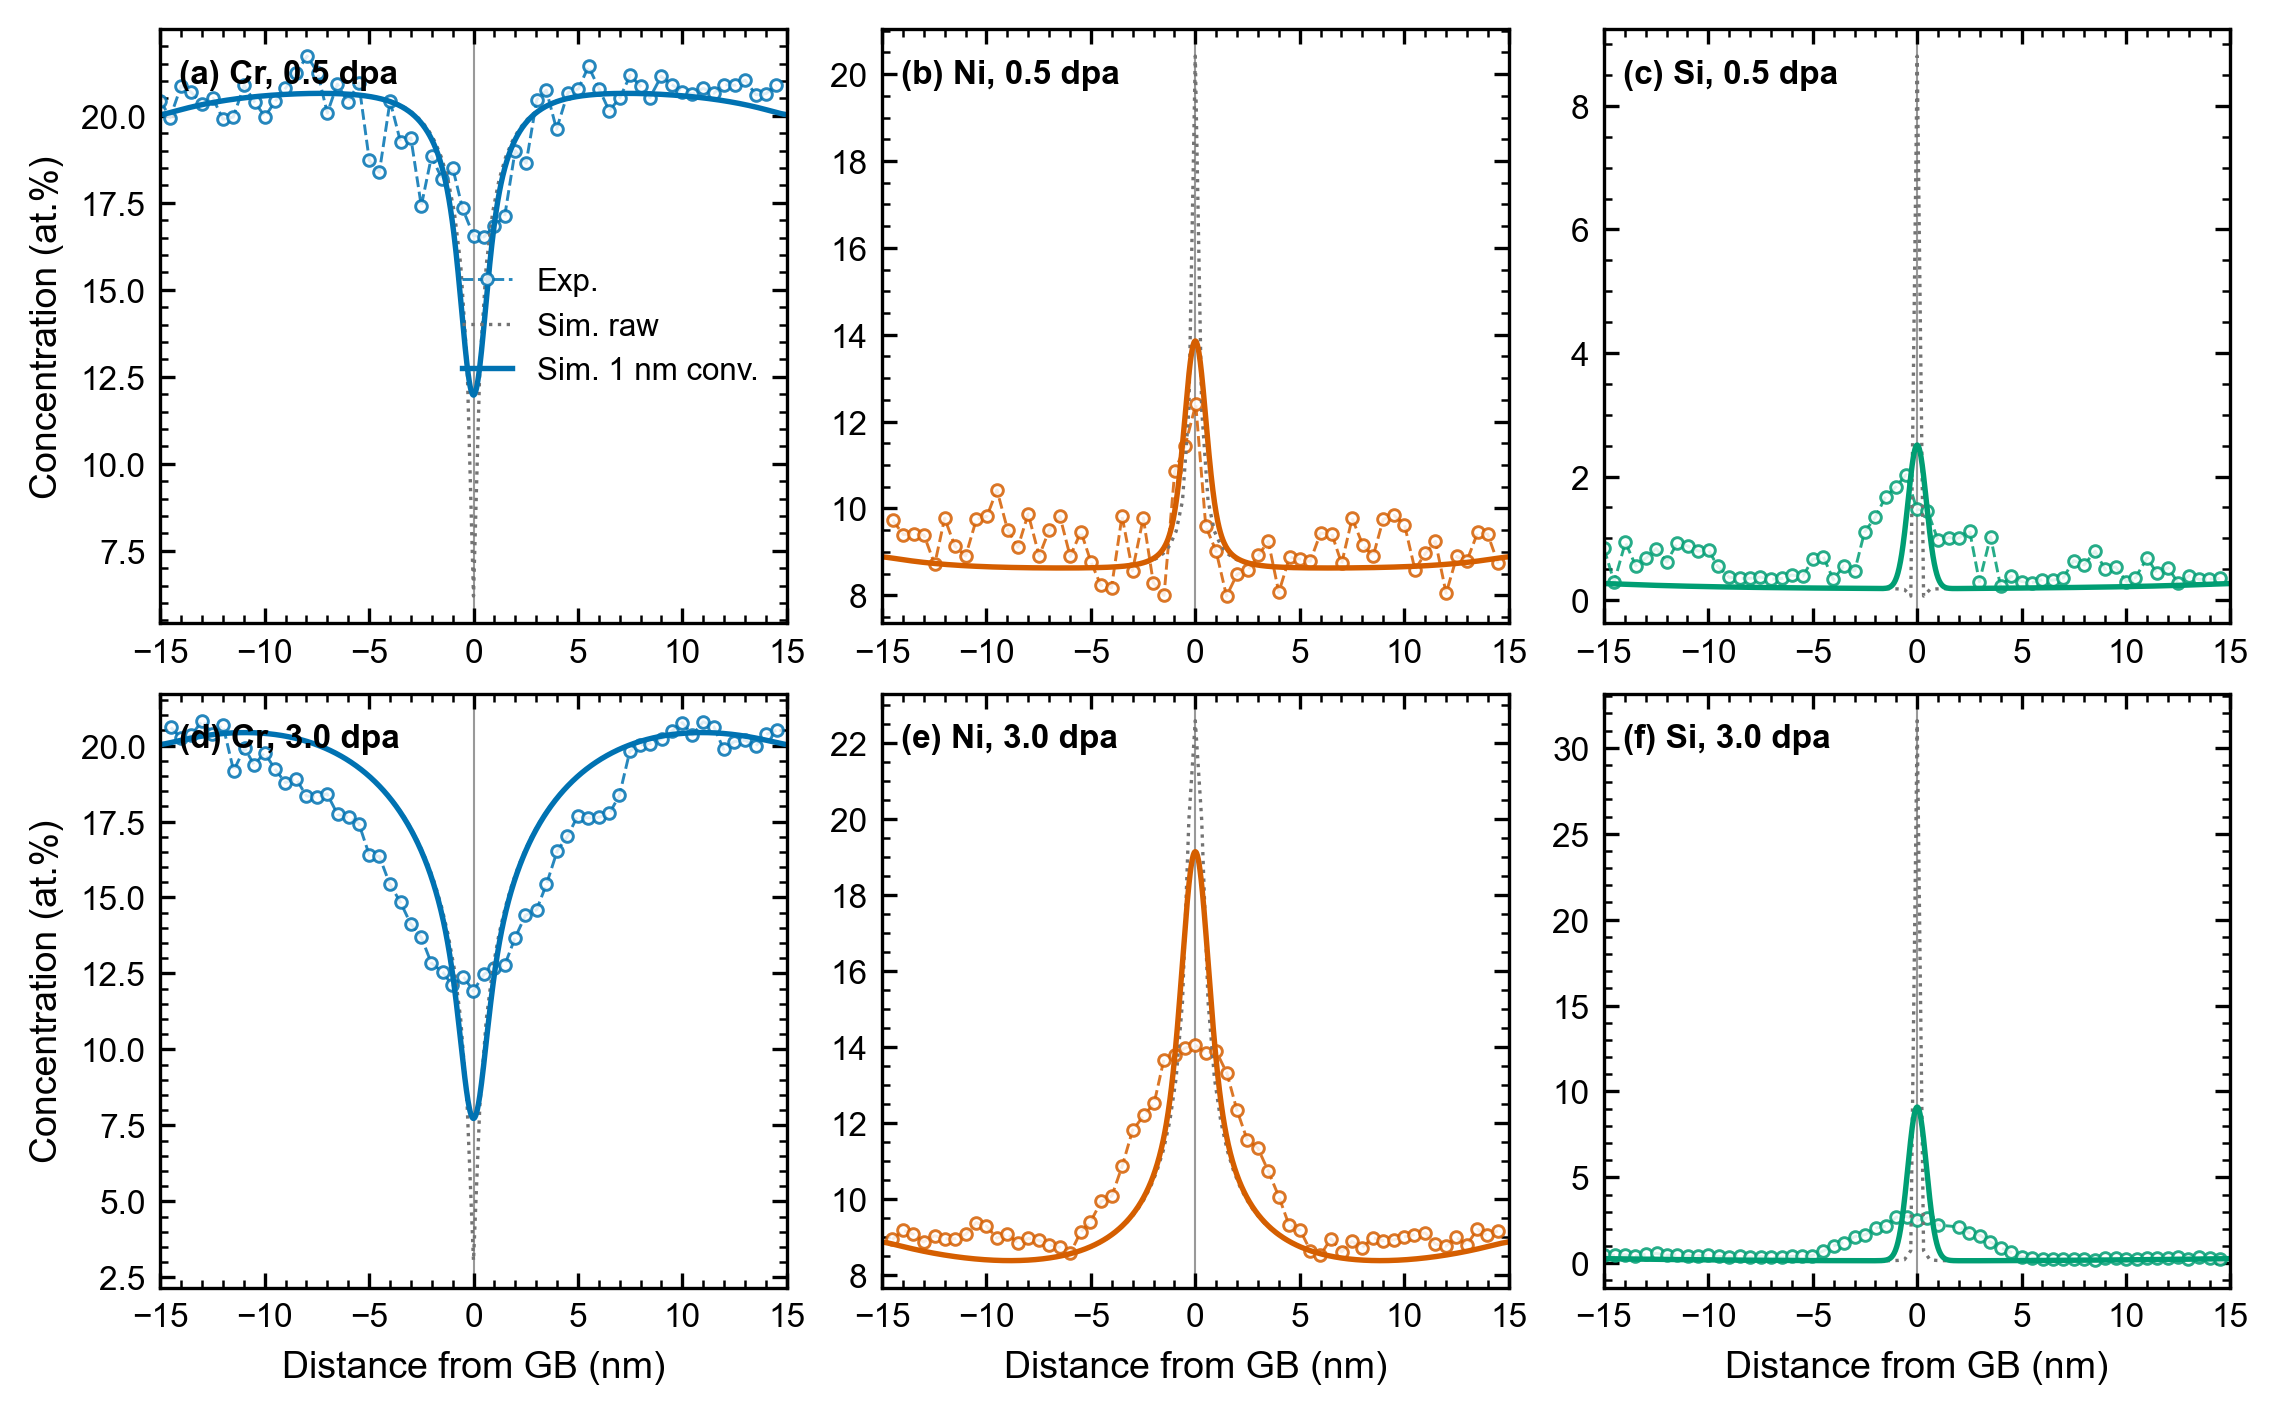

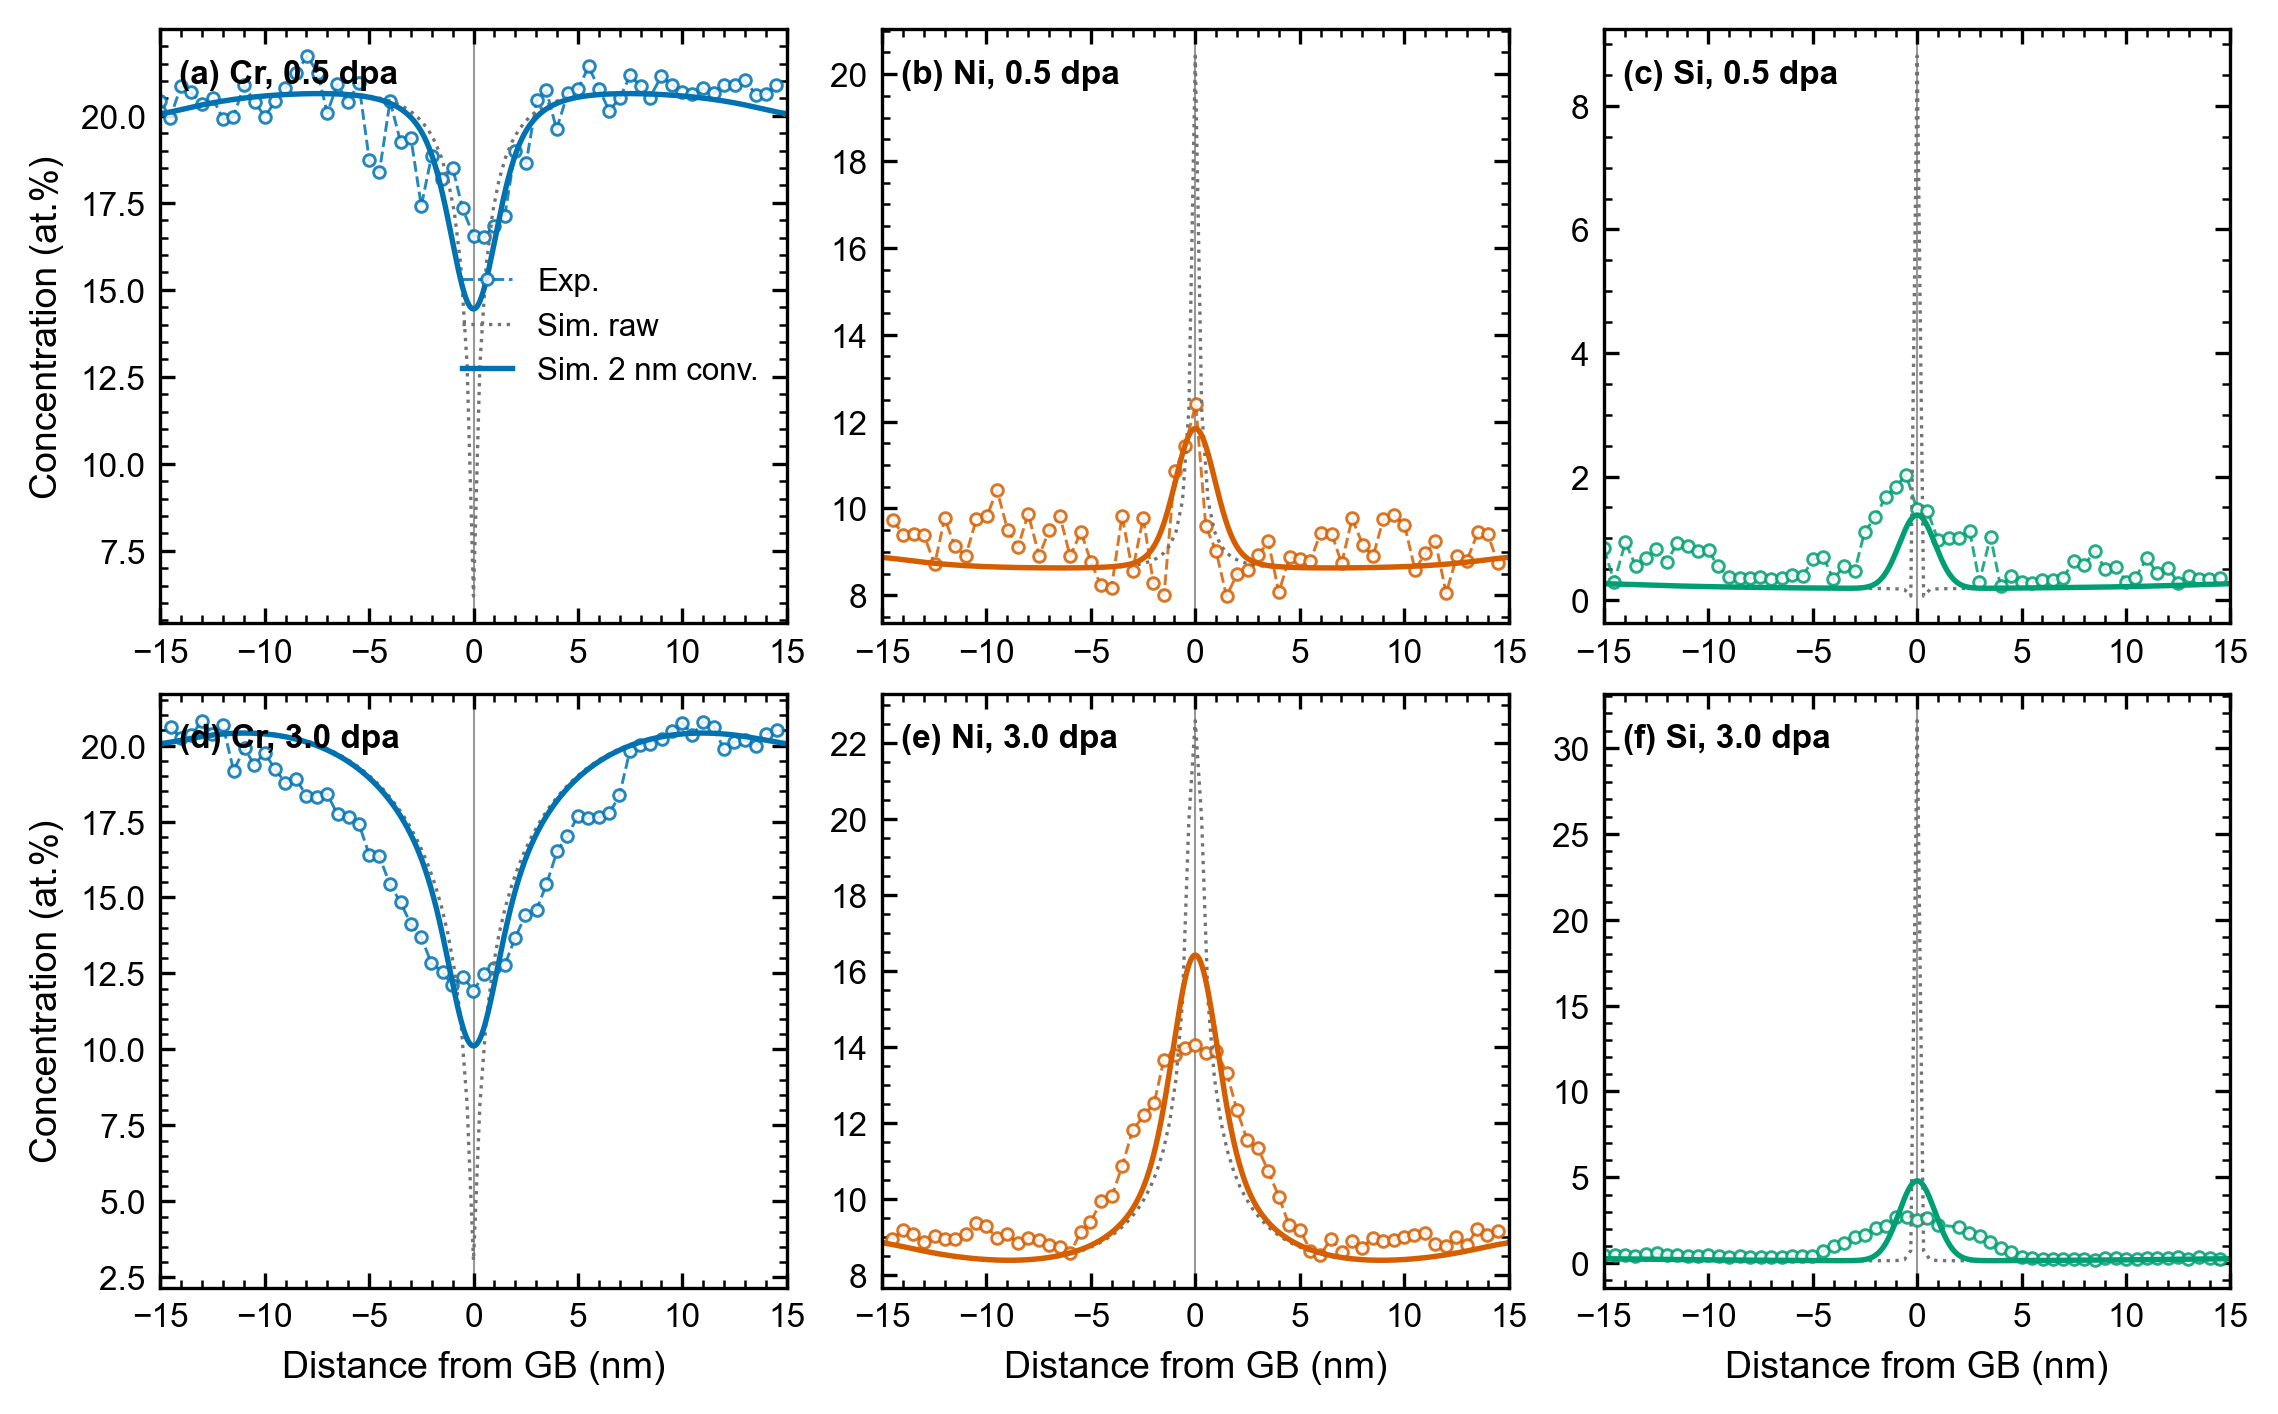

In [9]:
def overview(ds, convolved=False, fwhm=FWHM_NM):
    fig, axes = plt.subplots(len(DOSES), len(ELEMENTS),
                             figsize=(7.48, 4.6), constrained_layout=True)
    panel = iter('abcdef')
    for i, dose in enumerate(DOSES):
        for j, element in enumerate(ELEMENTS):
            ax = axes[i, j]
            xs, cs = cut(*sim[(ds, dose, element)])
            xe, ce = cut(*exp[(ds, dose, element)])
            color = COLORS[element]
            ax.plot(xe, ce, ls='--', lw=0.7, marker='o', ms=2.8,
                    mfc='white', mec=color, mew=0.7, color=color, alpha=0.85,
                    label='Exp.')
            if convolved:
                ax.plot(xs, cs, ls=':', lw=0.8, color='0.45', label='Sim. raw')
                xc, cc = cut(*SIM_CONV[fwhm][(ds, dose, element)])
                ax.plot(xc, cc, ls='-', lw=1.3, color=color,
                        label=f'Sim. {fwhm:g} nm conv.')
            else:
                ax.plot(xs, cs, ls='-', lw=1.3, color=color, label='Sim.')
            ax.axvline(0.0, ls='-', lw=0.5, color='0.6', zorder=0)
            ax.set_xlim(-X_CUT, X_CUT)
            ax.text(0.03, 0.95, f'({next(panel)}) {element}, {dose_label[dose]}',
                    transform=ax.transAxes, fontsize=8, fontweight='bold', va='top')
            if i == len(DOSES) - 1:
                ax.set_xlabel('Distance from GB (nm)')
            if j == 0:
                ax.set_ylabel('Concentration (at.%)')
            if i == 0 and j == 0:
                ax.legend(loc='center right', handlelength=1.6)
    if ds != '.':
        fig.suptitle(f'Dataset {ds}', fontsize=9, fontweight='bold')
    if not convolved:
        tag = 'raw'
    else:
        tag = 'conv' if fwhm == FWHM_NM else f'conv{fwhm:g}nm'
    stem = figdir(ds) / f'overview_{tag}'
    for ext in ('png', 'pdf'):
        fig.savefig(f'{stem}.{ext}')
    fig.savefig(f'{stem}.tiff', dpi=TIFF_DPI,
                pil_kwargs={'compression': 'tiff_lzw'})   # 1000 dpi LZW 压缩 TIFF
    return fig

for ds in DATASETS:
    overview(ds, convolved=False)
    overview(ds, convolved=True, fwhm=FWHM_NM)
    overview(ds, convolved=True, fwhm=FWHM_NM2)
plt.show()

## 第四轮：不同 dose 叠加在同一张图

每个元素一张图，把 0.5 dpa 与 3 dpa 画在一起（模拟卷积后 vs 实验）。
下方代码块可选择使用哪个卷积尺寸，改一行即可切换。

In [10]:
# ---------------- 叠加图设置：选择卷积尺寸 ----------------
# 改这一行即可切换分辨率：FWHM_NM = 1 nm，FWHM_NM2 = 2 nm
CONV_FWHM = FWHM_NM        # 现在用 1 nm；换 2 nm 改成 FWHM_NM2

# 不同 dose 的配色（叠加图专用，Okabe–Ito 色盲友好）
DOSE_COLORS = {DOSES[0]: '#0072B2',   # 蓝
               DOSES[1]: '#D55E00'}   # 朱红

print(f'叠加图使用卷积尺寸 FWHM = {CONV_FWHM:g} nm')

叠加图使用卷积尺寸 FWHM = 1 nm


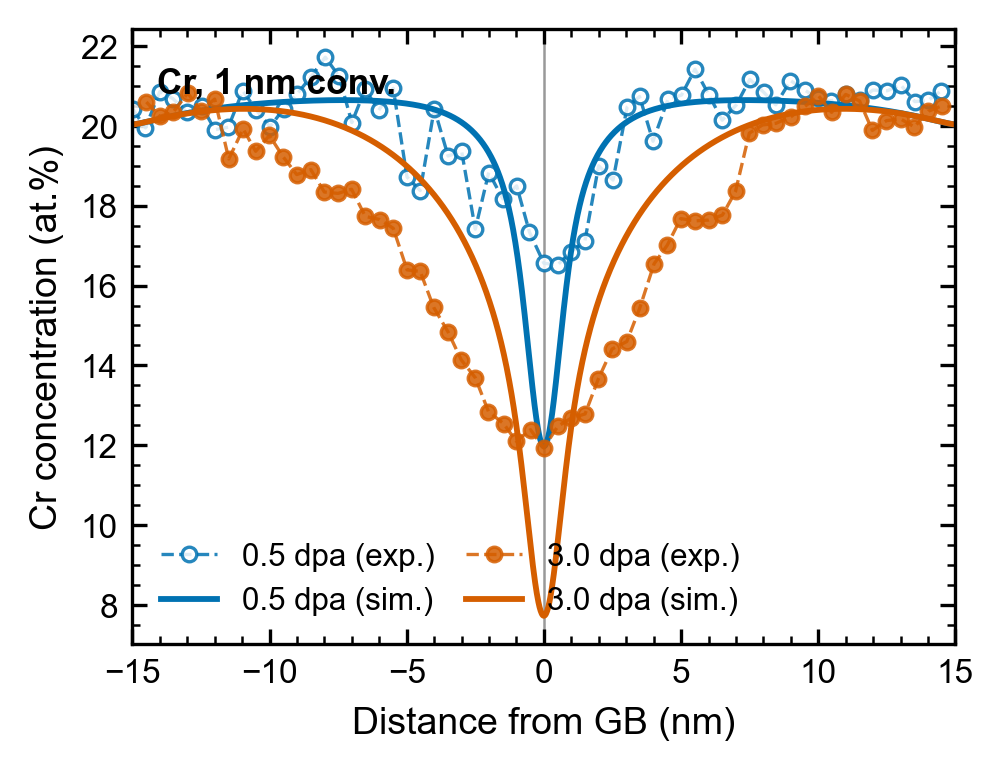

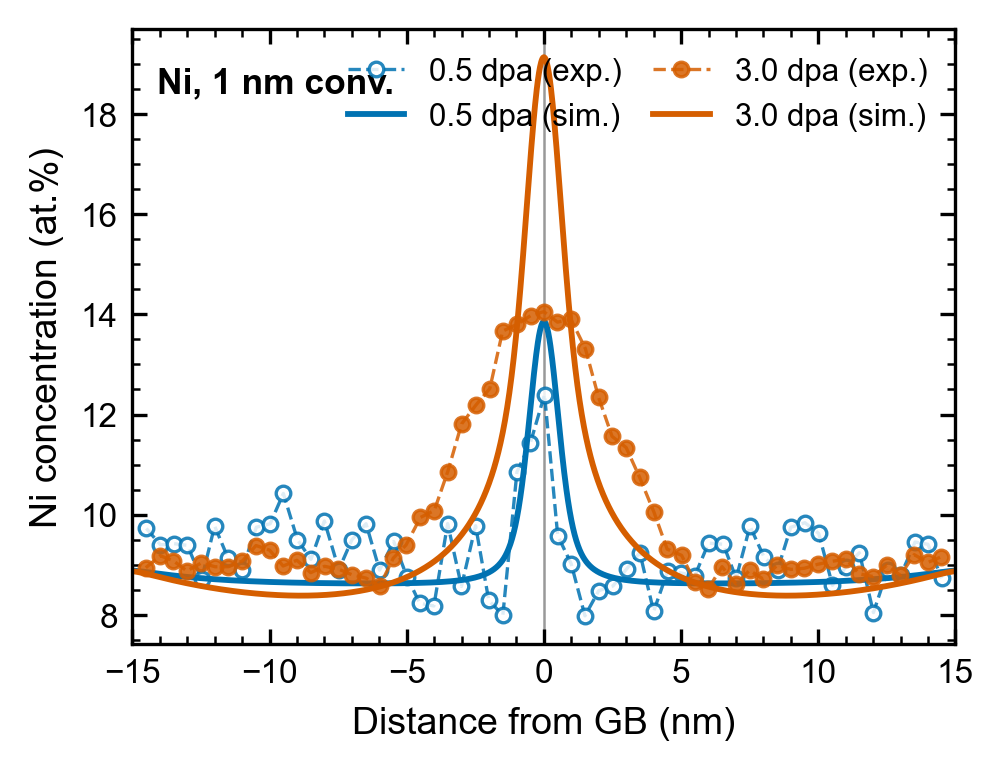

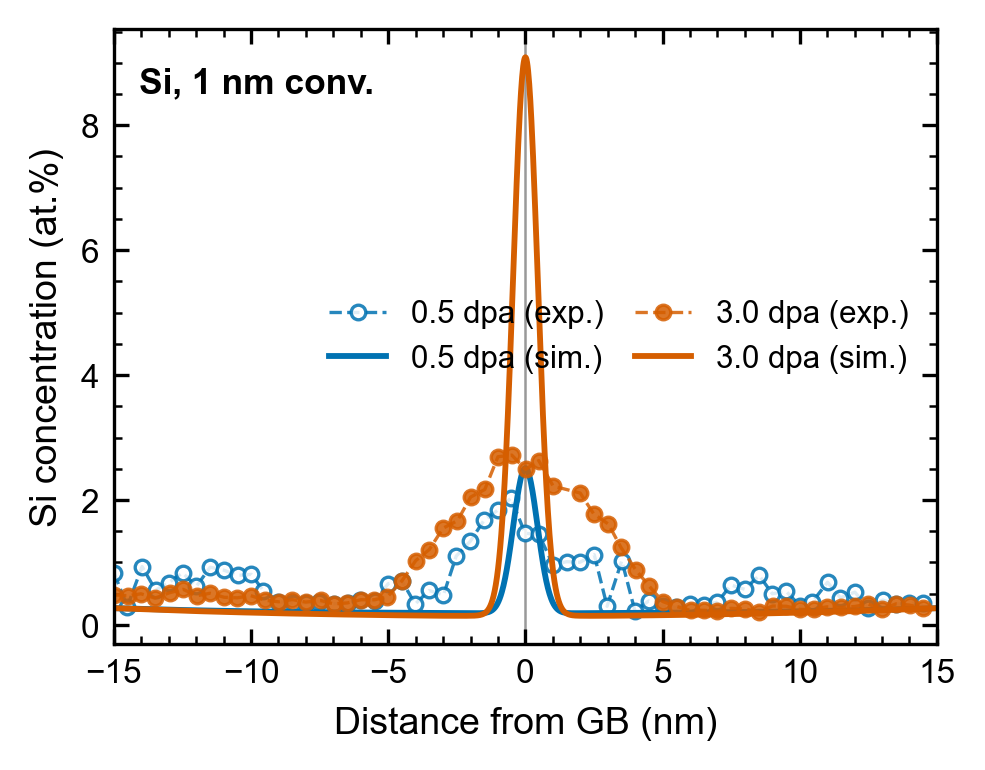

In [11]:
def plot_doses(ds, element, fwhm=CONV_FWHM, save=True):
    """同一元素、不同 dose 叠加在一张图：模拟（卷积后）实线 + 实验开口点。"""
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    for dose in DOSES:
        dcolor = DOSE_COLORS[dose]
        xe, ce = cut(*exp[(ds, dose, element)])
        xc, cc = cut(*SIM_CONV[fwhm][(ds, dose, element)])
        # 实验：3 dpa 用实心圆点，0.5 dpa 用开口圆点（细虚线）
        mface = dcolor if dose == DOSES[-1] else 'white'
        ax.plot(xe, ce, ls='--', lw=0.8, marker='o', ms=3.5,
                mfc=mface, mec=dcolor, mew=0.8, color=dcolor, alpha=0.85,
                label=f'{dose_label[dose]} (exp.)')
        # 模拟：实线
        ax.plot(xc, cc, ls='-', lw=1.4, color=dcolor,
                label=f'{dose_label[dose]} (sim.)')

    ax.axvline(0.0, ls='-', lw=0.6, color='0.6', zorder=0)   # GB 位置
    ax.set_xlim(-X_CUT, X_CUT)
    ax.set_xlabel('Distance from GB (nm)')
    ax.set_ylabel(f'{element} concentration (at.%)')
    ax.legend(loc='best', handlelength=1.8, ncol=2, columnspacing=1.0)
    ax.text(0.03, 0.94, f'{ds_tag(ds)}{element}, {fwhm:g} nm conv.',
            transform=ax.transAxes, fontsize=8.5, fontweight='bold', va='top')

    if save:
        stem = figdir(ds) / f'{element}_doses_conv{fwhm:g}nm'
        for ext in ('png', 'pdf'):
            fig.savefig(f'{stem}.{ext}')
        fig.savefig(f'{stem}.tiff', dpi=TIFF_DPI,
                    pil_kwargs={'compression': 'tiff_lzw'})   # 1000 dpi LZW 压缩 TIFF
    return fig

for ds in DATASETS:
    for element in ELEMENTS:
        plot_doses(ds, element, fwhm=CONV_FWHM)
plt.show()